# Step 21. All 260 patients, no split, no WGCNA

**Objective: does the interferon signature exist in this cohort, without any of the machinery?**

Steps 02 to 20 divide the 260 SLE patients into three artificial cohorts of about 87 to illustrate
federation. Everything downstream then inherits that split, and step 11 shows the split is not
harmless: the same parameters give 33, 15 and 37 modules, and cohort B puts 62% of the panel in one
module. This notebook does none of that. It uses all 260 patients at once and asks the question
directly.

**It also uses no WGCNA.** No soft-thresholding power, no `minModuleSize`, no module colours, no
merge threshold. Just the curated reagents, the patients, a distance and a linkage. Every parameter
that could be argued about is gone, so whatever is left is in the data.

**Recombining the three cohorts is legitimate**, and it is worth saying why rather than assuming it.
Step 00 runs ComBat **once, on all included samples, before the split** — `ComBat(dat = t(log2(X)),
batch = meta$Batch)` — and only then assigns patients to A, B and C. So the three matrices are slices
of one batch-corrected matrix, not three separately corrected ones, and stacking them restores
exactly what step 00 produced.

Reads `cohorts/R_cohort-{A,B,C}_log2_combat.csv` and `ifn_panel.csv`. Writes one figure.

## The patients and the reagents

In [1]:
source("../src/paths.R")
suppressMessages({library(ComplexHeatmap); library(circlize)})

X <- do.call(rbind, lapply(c("A", "B", "C"), function(s)
       read.csv(coh("R_cohort-%s_log2_combat.csv", s), row.names = 1, check.names = FALSE)))
m <- do.call(rbind, lapply(c("A", "B", "C"), function(s)
       read.csv(coh("R_cohort-%s_meta.csv", s), row.names = 1, check.names = FALSE)))
m <- m[rownames(X), , drop = FALSE]
stopifnot(!anyDuplicated(rownames(X)))

pan <- read.csv(art("ifn_panel.csv"), stringsAsFactors = FALSE)   # step 01b
pan$in_data <- pan$column %in% colnames(X)
IRG  <- pan$column[pan$set == "IRG-28"   & pan$in_data]
CTRL <- pan$column[pan$set == "NF-kB-11" & pan$in_data]
c(patients = nrow(X), reagents_measured = ncol(X),
  interferon_reagents = length(IRG), control_reagents = length(CTRL))

patients   reagents_measured interferon_reagents    control_reagents 
                260                7288                  12                  13

**Explanation**
- `do.call(rbind, lapply(...))` stacks the three cohort matrices back into one. They carry identical
  columns in identical order, and no patient appears twice, both of which the `stopifnot` and the
  duplicate check confirm rather than assume.
- `pan` is the panel step 01b resolved from `genes/`: the 28-gene interferon response score of Kim
  2018 and de Jesus 2020, and the 11 NF-kB-only control genes of de Jesus 2020, matched to the
  SomaScan reagents that measure them.
- `IRG` and `CTRL` are those two lists as column names. The control is the whole point: these are
  NF-kB target genes with no STAT1, STAT2 or TYK1 binding site, so they are immune proteins that
  should *not* track the interferon signature.

## Do these proteins move together? Correlation only, no clustering

In [2]:
Ci <- cor(X[, IRG]);  Cc <- cor(X[, CTRL]);  Cx <- cor(X[, IRG], X[, CTRL])
cat(sprintf("mean |r| within the %2d interferon reagents : %.3f\n", length(IRG),
            mean(abs(Ci[upper.tri(Ci)]))))
cat(sprintf("mean |r| within the %2d NF-kB-only controls : %.3f\n", length(CTRL),
            mean(abs(Cc[upper.tri(Cc)]))))
cat(sprintf("mean |r| interferon versus controls        : %.3f\n", mean(abs(Cx))))

core <- intersect(c("ISG15_seq.14148.2", "ISG15_seq.14151.4", "MX1", "IFIT3", "GBP1", "CXCL10"),
                  colnames(X))
Cr <- cor(X[, core])
cat("\nthe reagents that formed the module in cohort A, pairwise r over all 260:\n")
print(round(Cr, 2))
cat(sprintf("\nmean |r| among those %d: %.3f\n", length(core), mean(abs(Cr[upper.tri(Cr)]))))

mean |r| within the 12 interferon reagents : 0.302


mean |r| within the 13 NF-kB-only controls : 0.128


mean |r| interferon versus controls        : 0.131



the reagents that formed the module in cohort A, pairwise r over all 260:


                  ISG15_seq.14148.2 ISG15_seq.14151.4  MX1 IFIT3 GBP1 CXCL10
ISG15_seq.14148.2              1.00              0.98 0.81  0.74 0.65   0.54
ISG15_seq.14151.4              0.98              1.00 0.80  0.76 0.62   0.51
MX1                            0.81              0.80 1.00  0.74 0.69   0.55
IFIT3                          0.74              0.76 0.74  1.00 0.56   0.46
GBP1                           0.65              0.62 0.69  0.56 1.00   0.67
CXCL10                         0.54              0.51 0.55  0.46 0.67   1.00



mean |r| among those 6: 0.672


**Explanation**
- `cor()` on the raw log2 abundances. Nothing is fitted, thresholded or clustered; this is the
  correlation matrix itself.
- `upper.tri()` takes each pair once, so the diagonal of 1s does not inflate the mean.
- The third line is the comparison that matters. If the interferon reagents correlate with each other
  about as much as they correlate with the controls, there is no signature to find.
- `core` is the six reagents that made up the interferon module in cohort A's fit (step 02b). They
  are listed here to ask whether they still move together in the full cohort, where WGCNA does not
  call them a module.

**Result. The signature is in the data, and it is not WGCNA that puts it there.**

Mean `|r|` is **0.302** among the 12 interferon reagents against **0.128** among the 13 controls and
**0.131** between the two lists — so the interferon reagents are about 2.3 times more correlated with
each other than with anything in the control set, which is itself at the level of background.

The six core reagents average **0.672**, with the two ISG15 SOMAmers at 0.98, ISG15 to MX1 at 0.81 and
ISG15 to IFIT3 at 0.74.

**This matters because WGCNA on all 260 does not find them.** Fitting the published parameters to all
260 patients gives 11 modules, 2,163 reagents unassigned, a largest module covering 46% of the panel,
and the interferon reagents scattered: the plurality module holds 3 of the 12 with 6 in grey. More
patients produced a worse module than cohort A's 87 did. The correlations above show that this is a
property of the clustering at those parameters and not of the proteins.

## The heatmap: 260 patients, ward.D2, Minkowski p = 2, both axes

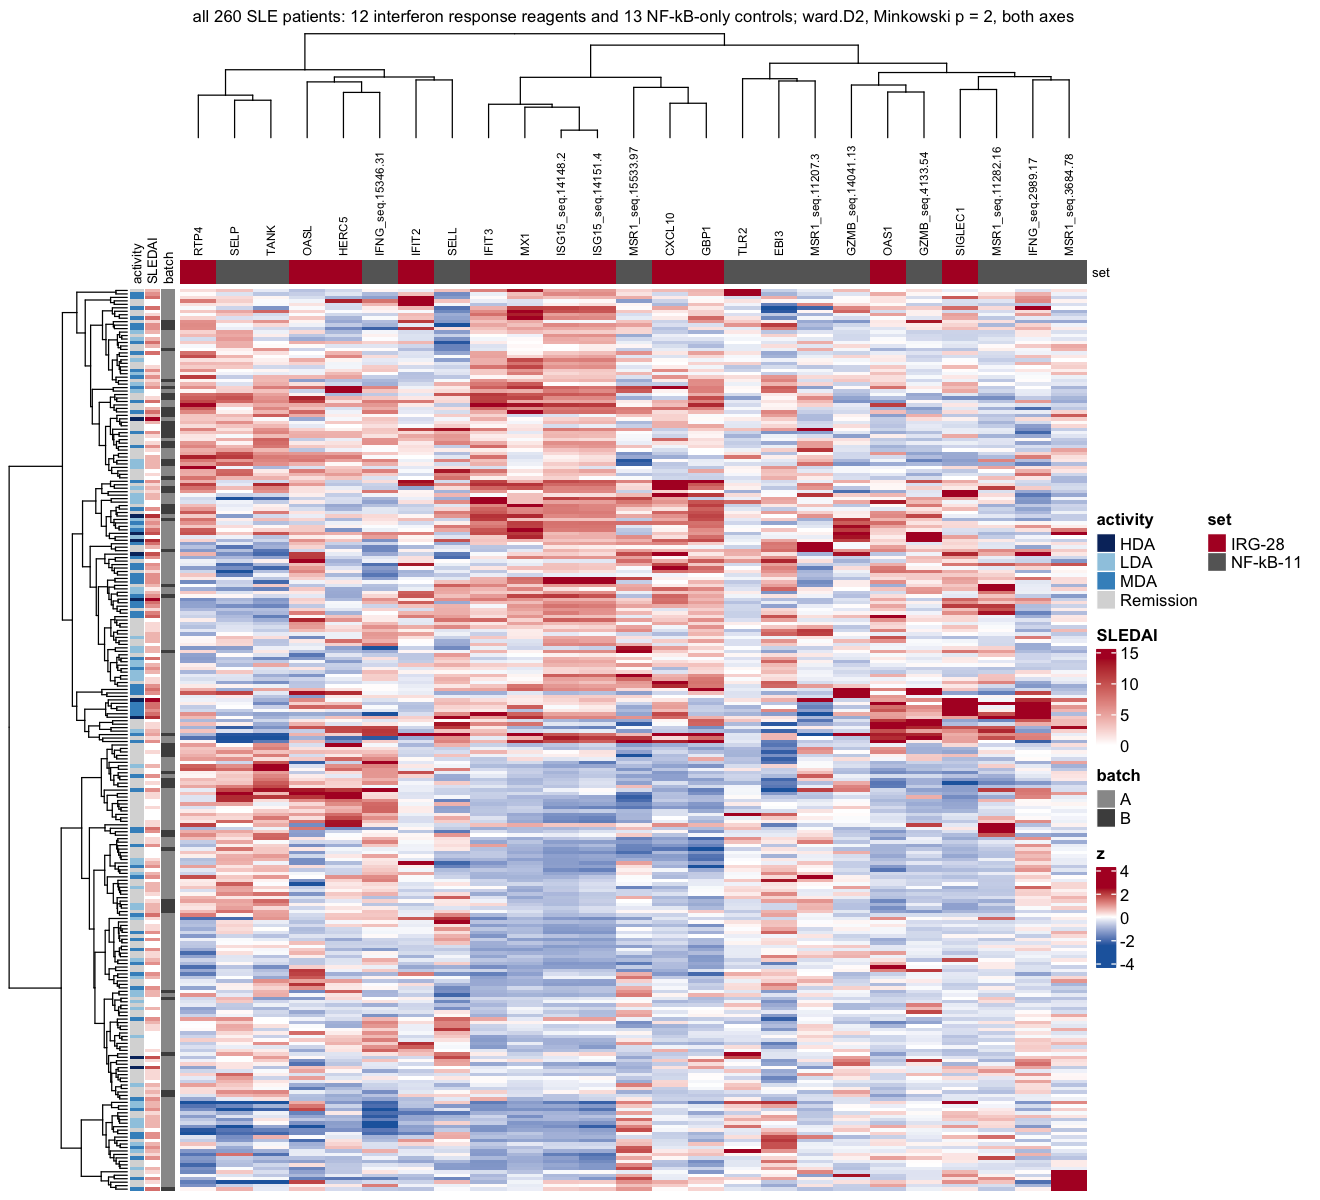

In [3]:
sel <- c(IRG, CTRL)
Z   <- scale(X[, sel, drop = FALSE])
Z   <- Z[, colSums(is.na(Z)) == 0, drop = FALSE]
Zc  <- pmin(pmax(Z, -2.5), 2.5)
gs  <- pan[match(colnames(Z), pan$column), ]

hc_rows <- hclust(dist(Z,    method = "minkowski", p = 2), method = "ward.D2")
hc_cols <- hclust(dist(t(Z), method = "minkowski", p = 2), method = "ward.D2")

top <- HeatmapAnnotation(
  set = gs$set,
  col = list(set = c("IRG-28" = "#B2182B", "NF-kB-11" = "grey40")),
  annotation_name_side = "right", annotation_name_gp = gpar(fontsize = 8))
left <- rowAnnotation(
  activity = m$Disease_activity, SLEDAI = m$SLEDAI_2K, batch = m$Batch, na_col = "grey92",
  annotation_name_side = "top",
  col = list(activity = c(Remission = "grey85", LDA = "#9ecae1", MDA = "#4292c6", HDA = "#08306b"),
             SLEDAI = colorRamp2(c(0, 14), c("white", "#B2182B")),
             batch = c(A = "grey60", B = "grey30")),
  annotation_name_gp = gpar(fontsize = 8), simple_anno_size = unit(3, "mm"))

figure <- function() {
  Heatmap(Zc, name = "z", col = colorRamp2(c(-2.5, 0, 2.5), c("#2166AC", "white", "#B2182B")),
          cluster_rows = hc_rows, cluster_columns = hc_cols,
          row_dend_side = "left", column_dend_side = "top",
          row_dend_width = unit(25, "mm"), column_dend_height = unit(22, "mm"),
          show_row_names = FALSE,
          column_names_side = "top", column_names_gp = gpar(fontsize = 7),
          top_annotation = top, left_annotation = left,
          column_title = sprintf("all %d SLE patients: %d interferon response reagents and %d NF-kB-only controls; ward.D2, Minkowski p = 2, both axes",
                                 nrow(Z), sum(gs$set == "IRG-28"), sum(gs$set == "NF-kB-11")),
          column_title_gp = gpar(fontsize = 10))
}
options(repr.plot.width = 11, repr.plot.height = 10)
for (device in c("inline", "png")) {               # the loop is explained in step 06
  if (device == "png") png(fig("21_all260_interferon.png"), width = 11, height = 10,
                           units = "in", res = 300)
  draw(figure())
  if (device == "png") invisible(dev.off())
}

**Explanation**
- `scale()` z-scores each reagent across all 260 patients, so colour is a patient's position relative
  to the whole cohort rather than to a third of it. `pmin(pmax(Z, -2.5), 2.5)` caps the colour so a
  few extreme patients do not flatten the rest.
- `dist(..., method = "minkowski", p = 2)` with `hclust(method = "ward.D2")` on both axes. Minkowski
  with p = 2 is Euclidean distance, written out so the exponent is visible rather than implied.
  `ward.D2` applies Ward's criterion to the distances themselves rather than their squares (Murtagh F,
  Legendre P. *J Classif* 2014;31:274-295).
- The only annotation is the one thing being tested — which list each reagent came from — plus
  disease activity, SLEDAI-2K and ComBat batch for the patients. Nothing else is on the figure.
- Names sit on the same side as their dendrogram on both axes. Patients are not named; there are 260
  and the tree carries the structure.

## Is that interferon branch actually supported? pvclust

The tree above is a picture; it does not say whether a branch would survive if the data were sampled
again. `pvclust` answers that by multiscale bootstrap resampling, giving each branch an **AU**
(approximately unbiased) p-value. AU is the better-calibrated of the two it reports, and a branch
with AU >= 0.95 is one the resampling did not break (Suzuki R, Shimodaira H. *Pvclust: an R package
for assessing the uncertainty in hierarchical clustering.* Bioinformatics 2006;22:1540-1542).

Same distance and linkage as the heatmap. `method.dist = "euclidean"` **is** Minkowski with p = 2 —
the same metric under the name pvclust uses for it.

**The reagent axis is bootstrapped, not the patient axis, and that is deliberate.** pvclust resamples
the *rows* of what it is given. Clustering the 25 reagents resamples 260 patients, which is a real
bootstrap. Clustering the 260 patients would resample 25 reagents, and 25 is far too few to bootstrap
meaningfully — it would produce AU values that look like evidence and are not. The transcriptomics
repository bootstraps patients because it has hundreds of probes to resample.

In [4]:
suppressMessages(library(pvclust))
set.seed(SEED)
pv <- pvclust(as.data.frame(Z), method.hclust = "ward.D2", method.dist = "euclidean",
              nboot = 1000, quiet = TRUE)          # euclidean == Minkowski p = 2

picked <- pvpick(pv, alpha = 0.95)
cat(sprintf("branches with AU >= 0.95: %d\n\n", length(picked$clusters)))
for (i in seq_along(picked$clusters)) {
  g <- picked$clusters[[i]]
  cat(sprintf("  [%d] %2d reagents (%d interferon, %d control): %s\n",
              i, length(g), sum(g %in% IRG), sum(g %in% CTRL), paste(g, collapse = ", ")))
}
saveRDS(list(pv = pv, picked = picked), art("step21_pvclust.rds"))

branches with AU >= 0.95: 2



  [1]  4 reagents (4 interferon, 0 control): IFIT3, ISG15_seq.14148.2, ISG15_seq.14151.4, MX1
  [2]  2 reagents (2 interferon, 0 control): CXCL10, GBP1


**Explanation**
- `pvclust(as.data.frame(Z), ...)` clusters the **columns** of `Z`, which are the 25 reagents, and
  resamples its rows, which are the 260 patients.
- `nboot = 1000` is the number of bootstrap replicates at each scale; `quiet = TRUE` suppresses the
  per-scale progress lines, which are noise in a rendered notebook.
- `pvpick(pv, alpha = 0.95)` returns the branches reaching AU >= 0.95, the ones the resampling did
  not break. It reports the largest such branch on each path, so nested supported branches appear
  once.
- For each supported branch the cell prints how many members came from the interferon list and how
  many from the control list. **That is the test:** a supported branch mixing the two lists is not an
  interferon signature.

**Result. Two branches survive the bootstrap, and both are pure interferon.**

Every branch reaching AU >= 0.95, checked exhaustively rather than read off the figure:

| AU | BP | members | interferon | control |
|---|---|---|---|---|
| 1.00 | 1.00 | ISG15 `seq.14148.2`, ISG15 `seq.14151.4` | 2 | **0** |
| 0.95 | 0.97 | IFIT3, MX1, ISG15 `seq.14148.2`, ISG15 `seq.14151.4` | 4 | **0** |
| 0.97 | 0.96 | CXCL10, GBP1 | 2 | **0** |
| 1.00 | 1.00 | all 25 reagents | 12 | 13 |

The first two are nested, which is why `pvpick()` reports two branches and not three: it returns the
largest supported branch on each path. The last row is the root, which contains everything by
construction and carries no information.

**Apart from the root, no branch containing a control reagent is supported.** Of 25 reagents the
resampling confirms exactly six, and all six come from the interferon list. That is the control doing
its job: the 13 NF-kB-only reagents fall into branches the bootstrap breaks, at AU 0.61 to 0.84.

**Six of the twelve interferon reagents are not supported either** — OASL, HERC5, IFIT2, RTP4,
SIGLEC1 and OAS1 sit in branches the bootstrap breaks. The signature that survives resampling in
plasma is a six-reagent core, not the whole score.

**The split between the two branches is not arbitrary, and this is the part worth noticing.** Branch 1
is IFIT3, ISG15 and MX1 — all from the 25 STAT1-only genes. Branch 2 is CXCL10 and GBP1, which are two
of the three genes de Jesus et al. single out as having **both** a STAT1 and an NF-kB binding site
(the third, SOCS1, is not on this SomaScan menu). So the bootstrap separates the STAT1-only reagents
from the STAT1-plus-NF-kB reagents, reproducing a distinction that was drawn in the literature from
transcription-factor binding sites rather than from expression, in plasma protein abundance, in a
different cohort.

That is an independent recovery of a published structural claim, and it needs no WGCNA, no module, no
`minModuleSize` and no artificial cohort split to see.

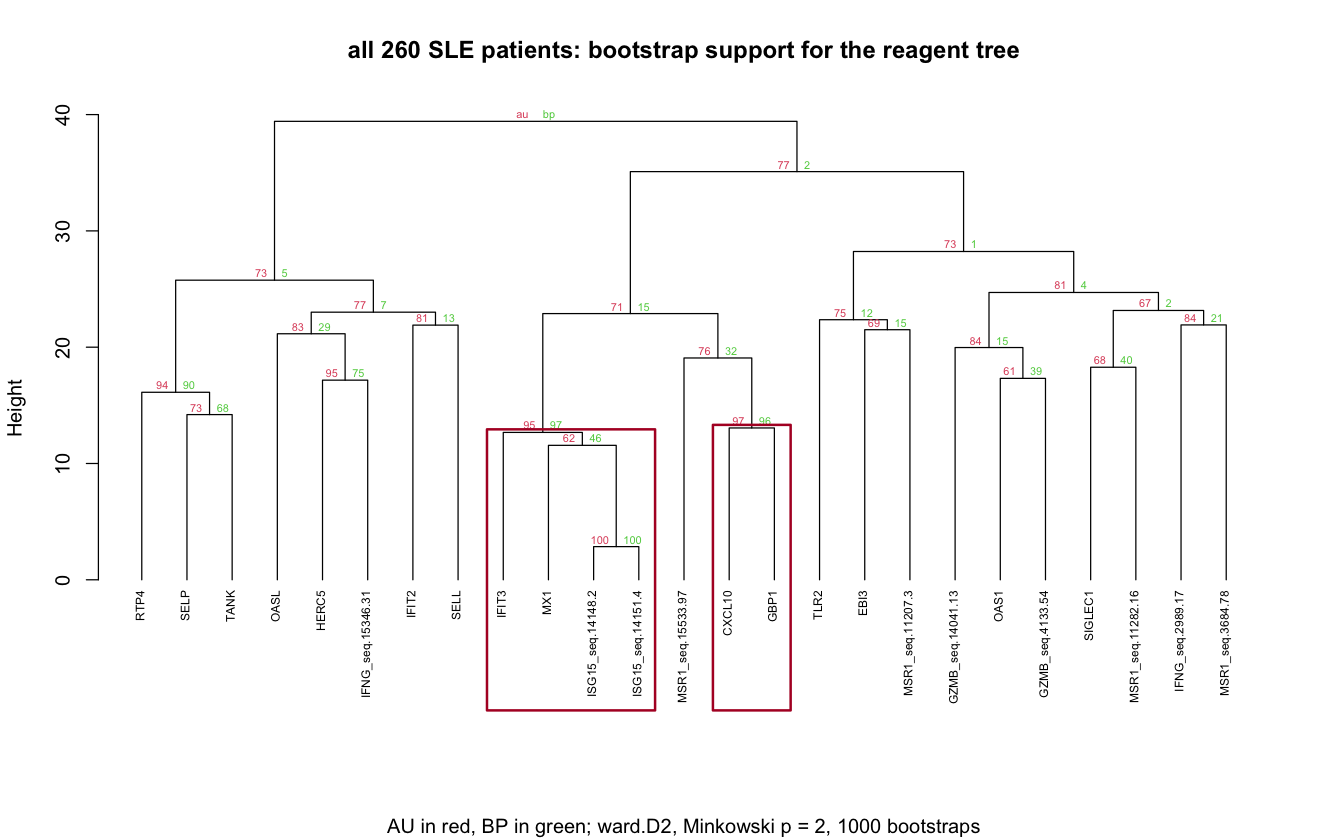

In [5]:
figure <- function() {
  plot(pv, hang = -1, cex = 0.6, cex.pv = 0.55, print.num = FALSE,
       main = "all 260 SLE patients: bootstrap support for the reagent tree",
       sub = "AU in red, BP in green; ward.D2, Minkowski p = 2, 1000 bootstraps", xlab = "")
  pvrect(pv, alpha = 0.95, border = "#B2182B", lwd = 2)
}
options(repr.plot.width = 11, repr.plot.height = 7)
for (device in c("inline", "png")) {               # the loop is explained in step 06
  if (device == "png") png(fig("21_all260_pvclust.png"), width = 11, height = 7,
                           units = "in", res = 300)
  figure()
  if (device == "png") invisible(dev.off())
}

**Explanation**
- `plot(pv)` draws the same tree with AU (red) and BP (green) printed at each branch.
- `pvrect(pv, alpha = 0.95)` boxes the branches reaching AU >= 0.95, so the supported structure can be
  seen without reading every number.
- `print.num = FALSE` drops pvclust's internal edge numbers, which carry no information here.

## Where this was run

In [6]:
# Provenance. The rendered notebook is committed, so it records where it ran.
# The cell is identical in every notebook and is explained in step 00.
si <- Sys.info()
cat("run on      :", si[["nodename"]], "(", si[["sysname"]], si[["release"]], ")\n")
cat("date        :", format(Sys.time(), "%Y-%m-%d %H:%M %Z"), "\n")
cat("R           :", R.version.string, "|", R.version$platform, "\n")
cat("R comes from:", R.home(), "\n")
cat("packages    :\n")
for (p in c("WGCNA", "ComplexHeatmap", "circlize", "pvclust", "ReactomePA", "reactome.db",
            "org.Hs.eg.db", "sva", "VarSelLCM"))
  cat(sprintf("   %-16s %s\n", p,
              tryCatch(as.character(packageVersion(p)), error = function(e) "not installed")))

run on      : Annes-MacBook-Pro-193.local ( Darwin 27.0.0 )


date        : 2026-09-28 02:52 EDT 


R           : R version 4.4.3 (2025-02-28) | x86_64-apple-darwin13.4.0 


R comes from: /Users/adeslatt/miniforge3/envs/endotypes-proteomics/lib/R 


packages    :


   WGCNA            1.74
   ComplexHeatmap   2.22.0
   circlize         0.4.18
   pvclust          2.2.0
   ReactomePA       1.50.0
   reactome.db      1.89.0
   org.Hs.eg.db     3.20.0
   sva              3.54.0
   VarSelLCM        2.1.3.2
